# Import required library

In [1]:
import cv2
import os
import glob
import random
import numpy as np
from tqdm import tqdm

from patchify import patchify
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf

# Set the environment variable

In [6]:
WORKING_DIR = r'data'
NUMBER_OF_IMAGES = 1 #Adjusted to match available sample data
IMG_WIDTH = 1024
IMG_HEIGHT = 1024
PATCH_SIZE = 256
IMG_CHANNEL = 3
IOU_THRESHOLD = 0.7

# Patches per image
NUMBER_OF_PATCHES_PER_IMG = int((IMG_WIDTH / PATCH_SIZE) * (IMG_WIDTH / PATCH_SIZE))
TOTAL_PATCHES = NUMBER_OF_IMAGES * NUMBER_OF_PATCHES_PER_IMG

# Preprocessing the data

The dataset is really huge. I don't need this much data for testing purpose. I am going to use only the 2000 dataset for this purpose.

In [7]:
TRAIN_IMG = sorted(glob.glob(WORKING_DIR + '/images/*.png'))
TRAIN_MASK = sorted(glob.glob(WORKING_DIR + '/targets/*.png'))

In [8]:
image_dataset = []
for i, img in tqdm(enumerate(TRAIN_IMG)):
    if i== NUMBER_OF_IMAGES:
        break
    img_before_patch = cv2.imread(img) / 255
    img_patches = patchify(img_before_patch, (PATCH_SIZE, PATCH_SIZE, 3), step=PATCH_SIZE)
    img_patches = img_patches.reshape((NUMBER_OF_PATCHES_PER_IMG, PATCH_SIZE, PATCH_SIZE, 3))
    image_dataset.append(img_patches)

1it [00:00, 16.89it/s]


In [9]:
image_dataset = np.array(image_dataset).reshape((NUMBER_OF_IMAGES * NUMBER_OF_PATCHES_PER_IMG, PATCH_SIZE, PATCH_SIZE, IMG_CHANNEL))
image_dataset.shape

(16, 256, 256, 3)

In [10]:
mask_dataset = []
for i, mask in tqdm(enumerate(TRAIN_MASK)):
    if i == NUMBER_OF_IMAGES:
        break
    mask_before_patch = cv2.imread(mask)[:, :, 0]
    mask_patches = patchify(mask_before_patch, (PATCH_SIZE, PATCH_SIZE), step=PATCH_SIZE)
    mask_patches = mask_patches.reshape((NUMBER_OF_PATCHES_PER_IMG, PATCH_SIZE, PATCH_SIZE))
    mask_dataset.append(mask_patches)

1it [00:00, 33.77it/s]


In [11]:
mask_dataset = np.array(mask_dataset).reshape((NUMBER_OF_IMAGES * NUMBER_OF_PATCHES_PER_IMG, PATCH_SIZE, PATCH_SIZE, 1))
mask_dataset.shape

(16, 256, 256, 1)

In [12]:
print(image_dataset.shape, mask_dataset.shape)

(16, 256, 256, 3) (16, 256, 256, 1)


In [13]:
# All the data that has more than 1 is building
# np.where(condition, true_statement, false_statement)
mask_dataset = np.where(mask_dataset > 0, 1, 0)

In [14]:
zero_indices = []
for i, mask in tqdm(enumerate(mask_dataset)):
    if(np.all(mask==0)):
        zero_indices.append(i)

16it [00:00, 2651.48it/s]


In [15]:
image_dataset = np.delete(image_dataset, zero_indices, axis=0)
mask_dataset = np.delete(mask_dataset, zero_indices, axis=0)

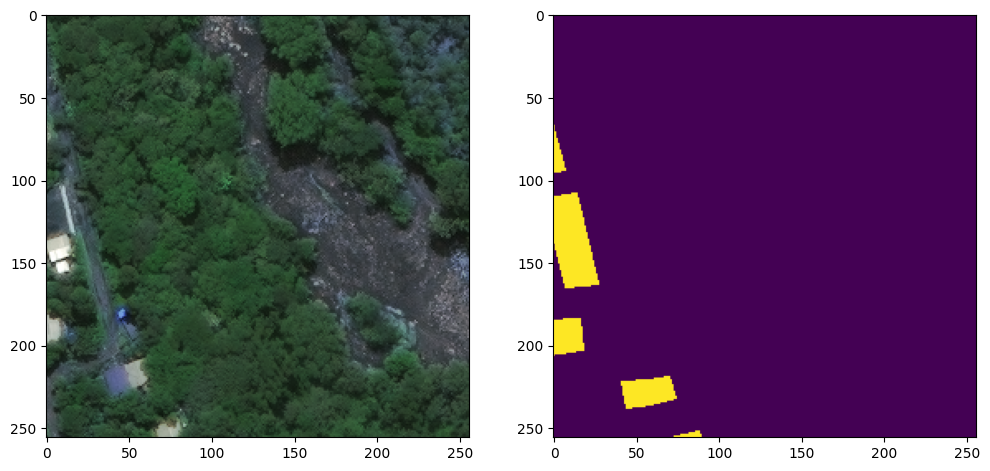

In [16]:
image_number = random.randint(0, len(image_dataset))

plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(np.uint8(image_dataset[image_number] * 255))
plt.subplot(122)
plt.imshow(mask_dataset[image_number])
plt.show()

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(image_dataset, mask_dataset, test_size = 0.20, random_state = 42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(8, 256, 256, 3) (3, 256, 256, 3) (8, 256, 256, 1) (3, 256, 256, 1)


# Unet Model

In [18]:
def unet_model(IMG_WIDTH, IMG_HIGHT, IMG_CHANNELS):
    inputs = tf.keras.layers.Input((IMG_WIDTH, IMG_HIGHT, IMG_CHANNELS))

    # Converted inputs to floating
    #s = tf.keras.layers.Lambda(lambda x: x / 255)(inputs)


    #Contraction path
    c1 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    c1 = tf.keras.layers.Dropout(0.1)(c1)
    c1 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    p1 = tf.keras.layers.MaxPooling2D((2, 2))(c1)

    c2 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = tf.keras.layers.Dropout(0.1)(c2)
    c2 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    p2 = tf.keras.layers.MaxPooling2D((2, 2))(c2)

    c3 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = tf.keras.layers.Dropout(0.2)(c3)
    c3 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    p3 = tf.keras.layers.MaxPooling2D((2, 2))(c3)

    c4 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
    c4 = tf.keras.layers.Dropout(0.2)(c4)
    c4 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
    p4 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(c4)

    c5 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
    c5 = tf.keras.layers.Dropout(0.3)(c5)
    c5 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)

    #Expansive path 
    u6 = tf.keras.layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = tf.keras.layers.concatenate([u6, c4])
    c6 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = tf.keras.layers.Dropout(0.2)(c6)
    c6 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)

    u7 = tf.keras.layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = tf.keras.layers.concatenate([u7, c3])
    c7 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = tf.keras.layers.Dropout(0.2)(c7)
    c7 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)

    u8 = tf.keras.layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = tf.keras.layers.concatenate([u8, c2])
    c8 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
    c8 = tf.keras.layers.Dropout(0.1)(c8)
    c8 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)

    u9 = tf.keras.layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = tf.keras.layers.concatenate([u9, c1], axis=3)
    c9 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
    c9 = tf.keras.layers.Dropout(0.1)(c9)
    c9 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)

    outputs = tf.keras.layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = tf.keras.Model(inputs=[inputs], outputs=[outputs])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

In [19]:
model = unet_model(PATCH_SIZE, PATCH_SIZE, IMG_CHANNEL)
# model.summary()

In [20]:
checkpointer = tf.keras.callbacks.ModelCheckpoint("model_output.h5", verbose=1, save_best_only=True)

callbacks = [
    #tf.keras.callbacks.EarlyStopping(patience=3, monitor='val_loss'),
    tf.keras.callbacks.TensorBoard(log_dir="logs"),
    checkpointer
    ]

In [21]:
history = model.fit(X_train, y_train, validation_split=0.1, batch_size=16, epochs=100, callbacks=callbacks)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3344 - loss: 0.7158
Epoch 1: val_loss improved from None to 0.66886, saving model to model_output.h5



Epoch 1: finished saving model to model_output.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.3344 - loss: 0.7158 - val_accuracy: 0.9707 - val_loss: 0.6689
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.7824 - loss: 0.6678
Epoch 2: val_loss improved from 0.66886 to 0.58609, saving model to model_output.h5



Epoch 2: finished saving model to model_output.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 719ms/step - accuracy: 0.7824 - loss: 0.6678 - val_accuracy: 0.9930 - val_loss: 0.5861
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.8901 - loss: 0.5302
Epoch 3: val_loss improved from 0.58609 to 0.17919, saving model to model_output.h5



Epoch 3: finished saving model to model_output.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 623ms/step - accuracy: 0.8901 - loss: 0.5302 - val_accuracy: 0.9932 - val_loss: 0.1792
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/step - accuracy: 0.9079 - loss: 0.9009
Epoch 4: val_loss did not improve from 0.17919
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step - accuracy: 0.9079 - loss: 0.9009 - val_accuracy: 0.9932 - val_loss: 0.4834
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.9119 - loss: 0.4511
Epoch 5: val_loss did not improve from 0.17919
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 534ms/step - accuracy: 0.9119 - loss: 0.4511 - val_accuracy: 0.9932 - val_loss: 0.5776
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.9149 - loss: 0.5375
Epoch 6: val_loss did not improve from 0.17919
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step - accuracy: 0.9149 - loss: 0.5375 - val_accuracy: 0.9932 - val_loss: 0.5881
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - accuracy: 0.9158 - loss: 0.5670
Epoch 7:


Epoch 23: finished saving model to model_output.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 823ms/step - accuracy: 0.9167 - loss: 0.3528 - val_accuracy: 0.9932 - val_loss: 0.1679
Epoch 24/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 565ms/step - accuracy: 0.9167 - loss: 0.3471
Epoch 24: val_loss improved from 0.16795 to 0.14784, saving model to model_output.h5


...


Epoch 39: finished saving model to model_output.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 586ms/step - accuracy: 0.9168 - loss: 0.1779 - val_accuracy: 0.9932 - val_loss: 0.0440
Epoch 40/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 635ms/step - accuracy: 0.9170 - loss: 0.1781
Epoch 40: val_loss did not improve from 0.04402
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 671ms/step - accuracy: 0.9170 - loss: 0.1781 - val_accuracy: 0.9932 - val_loss: 0.0444
Epoch 41/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.9174 - loss: 0.1780
Epoch 41: val_loss did not improve from 0.04402
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 517ms/step - accuracy: 0.9174 - loss: 0.1780 - val_accuracy: 0.9932 - val_loss: 0.0460
Epoch 42/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 541ms/step - accuracy: 0.9183 - loss: 0.1767
Epoch 42: val_loss did not improve from 0.04402
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 587ms/step - accuracy: 0.9183 - loss: 0.1767 - val_accuracy: 0.9932 - val_loss: 0.0472
Epoch 43/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 529ms/step - accuracy: 0.9192 - loss: 0.1776



Epoch 69: finished saving model to model_output.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 706ms/step - accuracy: 0.9443 - loss: 0.1476 - val_accuracy: 0.9840 - val_loss: 0.0415
Epoch 70/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.9457 - loss: 0.1454
Epoch 70: val_loss improved from 0.04152 to 0.03519, saving model to model_output.h5



Epoch 70: finished saving model to model_output.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 602ms/step - accuracy: 0.9457 - loss: 0.1454 - val_accuracy: 0.9883 - val_loss: 0.0352
Epoch 71/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.9453 - loss: 0.1481
Epoch 71: val_loss did not improve from 0.03519
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 575ms/step - accuracy: 0.9453 - loss: 0.1481 - val_accuracy: 0.9814 - val_loss: 0.0431
Epoch 72/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 749ms/step - accuracy: 0.9469 - loss: 0.1410
Epoch 72: val_loss did not improve from 0.03519
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 798ms/step - accuracy: 0.9469 - loss: 0.1410 - val_accuracy: 0.9743 - val_loss: 0.0473
Epoch 73/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/step - accuracy: 0.9444 - loss: 0.1424
Epoch 73: val_loss did not improve from 0.03519
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step - accuracy: 0.9444 - loss: 0.1424 - val_accuracy: 0.9739 - val_loss: 0.0469
Epoch 74/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - accuracy: 0.9440 - loss: 0.1439



Epoch 81: finished saving model to model_output.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 579ms/step - accuracy: 0.9504 - loss: 0.1318 - val_accuracy: 0.9924 - val_loss: 0.0264
Epoch 82/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 514ms/step - accuracy: 0.9474 - loss: 0.1429
Epoch 82: val_loss did not improve from 0.02639
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 551ms/step - accuracy: 0.9474 - loss: 0.1429 - val_accuracy: 0.9758 - val_loss: 0.0537
Epoch 83/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.9361 - loss: 0.1511
Epoch 83: val_loss did not improve from 0.02639
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 544ms/step - accuracy: 0.9361 - loss: 0.1511 - val_accuracy: 0.9771 - val_loss: 0.0483
Epoch 84/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 625ms/step - accuracy: 0.9408 - loss: 0.1406
Epoch 84: val_loss did not improve from 0.02639
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 663ms/step - accuracy: 0.9408 - loss: 0.1406 - val_accuracy: 0.9878 - val_loss: 0.0340
Epoch 85/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 524ms/step - accuracy: 0.9533 - loss: 0.1301



Epoch 100: finished saving model to model_output.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 670ms/step - accuracy: 0.9561 - loss: 0.1122 - val_accuracy: 0.9923 - val_loss: 0.0255


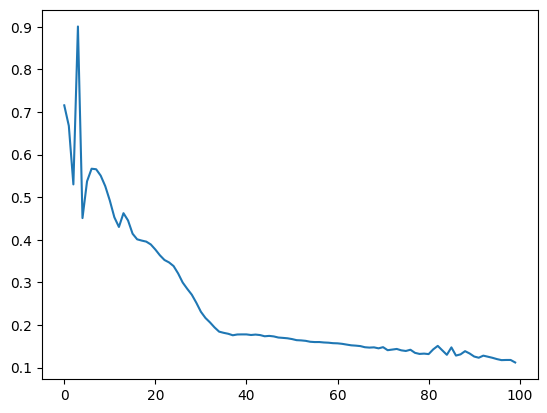

In [22]:
plt.plot(history.history['loss'])
plt.show()

# Result analysis

In [23]:
#IOU
y_pred=model.predict(X_test)
y_pred_argmax=np.argmax(y_pred, axis=3)
y_test_argmax=np.argmax(y_test, axis=3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step


In [24]:
#Using built in keras function for IoU
from tensorflow.keras.metrics import MeanIoU
n_classes = 2
IOU_keras = MeanIoU(num_classes=n_classes)  
IOU_keras.update_state(y_test_argmax, y_pred_argmax)
print("Mean IoU =", IOU_keras.result().numpy())

Mean IoU = 0.9999999


In [25]:
preds_train = model.predict(X_test, verbose=1)
preds_train_t = (preds_train > IOU_THRESHOLD).astype(np.uint8)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


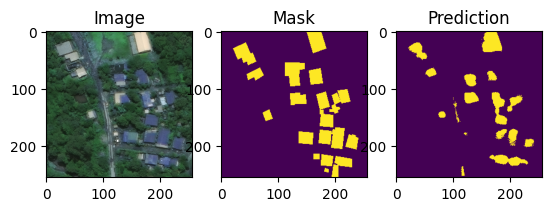

In [27]:
ix = random.randint(0, len(preds_train_t) - 1)

fig, (ax1, ax2, ax3) = plt.subplots(1,3)
ax1.imshow(np.uint8(X_test[ix] * 255))
ax1.set_title("Image")
ax2.imshow(y_test[ix].astype(int))
ax2.set_title("Mask")
ax3.imshow(preds_train_t[ix].astype(int))
ax3.set_title("Prediction")
plt.show()